In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pickle
import os
from collections import defaultdict
from sklearn.preprocessing import MinMaxScaler

In [2]:
class SwinehartAbbottNetworkMultiLayer(nn.Module):
    def __init__(self, L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=0.9, manual_weights=None):
        super(SwinehartAbbottNetworkMultiLayer, self).__init__()

        # L1 is the input layer. L3 is the output layer.
        self.L1_size = L1_size
        self.L1_gains = torch.full((L1_size,1), init_gain, requires_grad=True, dtype=torch.float32)
        self.L1_shifts = torch.full((L1_size,1), init_shift, requires_grad=True, dtype=torch.float32)
        init_L1_weight = (1 / L1_size) * int(L1_size * alpha)
        self.alpha = alpha
        if manual_weights == None: 
            #self.L1_weights = torch.full((L2_size, L1_size), init_L1_weight, requires_grad=False, dtype=torch.float32)
            init_L1_weights = torch.rand((L2_size, L1_size), requires_grad=False, dtype=torch.float32)
            init_L1_weights /= init_L1_weights.sum(dim=1, keepdim=True)
            self.L1_weights = init_L1_weights * int(L1_size * alpha)

            self.L1_mask = torch.from_numpy(np.random.choice([1, 0], size=self.L1_weights.shape, p=[connect_prob, 1-connect_prob]))
        else:
            self.L1_weights = torch.from_numpy(manual_weights['L1_weights'])
            self.L1_mask = torch.from_numpy(manual_weights['L1_mask'])

        self.L2_size = L2_size
        self.L2_gains = torch.full((L2_size,1), init_gain, requires_grad=True, dtype=torch.float32)
        self.L2_shifts = torch.full((L2_size,1), init_shift, requires_grad=True, dtype=torch.float32)
        init_L2_weight = (1 / L2_size) * int(L2_size * alpha)
        if manual_weights == None: 
            #self.L2_weights = torch.full((L3_size, L2_size), init_L2_weight, requires_grad=False, dtype=torch.float32)
            init_L2_weights = torch.rand((L3_size, L2_size), requires_grad=False, dtype=torch.float32)
            init_L2_weights /= init_L2_weights.sum(dim=1, keepdim=True)
            self.L2_weights = init_L2_weights * int(L2_size * alpha)

            self.L2_mask = torch.from_numpy(np.random.choice([1, 0], size=self.L2_weights.shape, p=[connect_prob, 1-connect_prob]))
        else:
            self.L2_weights = torch.from_numpy(manual_weights['L2_weights'])
            self.L2_mask = torch.from_numpy(manual_weights['L2_mask'])

        self.L3_size = L3_size
        self.L3_gains = torch.full((L3_size,), init_gain, requires_grad=False, dtype=torch.float32)
        self.L3_shifts = torch.full((L3_size,), init_shift, requires_grad=False, dtype=torch.float32)

        self.activation_func = nn.Sigmoid()


    
    def normal_pdf(self, theta):
        return 1.5 * torch.exp(-(theta ** 2)/2) - 0.5
    

    def gaussian_rf(self, x):
        theta_is = torch.linspace(0, 2 * torch.pi, self.L1_size).view(-1,1)
        return self.normal_pdf(x-theta_is) + self.normal_pdf(x-theta_is+2*torch.pi) + self.normal_pdf(x-theta_is-2*torch.pi)

    def forward(self, stimulus):

        L1_inputs = self.gaussian_rf(stimulus)

        L1_activations = self.activation_func(self.L1_gains * (L1_inputs - self.L1_shifts))
        L1_mat = torch.mul(self.L1_weights, self.L1_mask) # binary connection mask
        L2_inputs = torch.matmul(L1_mat, L1_activations)

        
        L2_activations = self.activation_func(self.L2_gains * (L2_inputs - self.L2_shifts)) 
        L2_mat = torch.mul(self.L2_weights, self.L2_mask) # binary connection mask
        L3_inputs = torch.matmul(L2_mat, L2_activations) # If we were to keep adding layers these would be added on


        # Save Vars
        self.L1_inputs = L1_inputs.clone()
        self.L1_activations = L1_activations.clone()
        self.L2_inputs = L2_inputs.clone()
        self.L2_activations = L2_activations.clone()
        self.L3_activations = L3_inputs.clone()

        return L3_inputs

# Multi Output Node Simulation

In [6]:
# Model Params ::
L1_size = 200
L2_size = 150 
L3_size = 20 
init_gain = 3
init_shift = 1
conProb = 0.3 
alpha = 0.25 # defines the fraction of the layer size
L1_alpha = int(L1_size * alpha) 
L2_alpha = int(L2_size * alpha) 
torch.manual_seed(42)


# Data Generation :: 
ndata = 50
xs = torch.linspace(0, 2 * torch.pi, ndata)

output_targ_shifts = torch.linspace(0, 2*torch.pi, L3_size)
target_outputs = torch.zeros((L3_size, ndata))
for ind, shift in enumerate(output_targ_shifts):
    target_outputs[ind,:] = torch.cos(xs - shift)/4 + 0.5 # Make the target outputs many shifted cosines



# Training Params ::
num_epochs = 10000
num_train_data = ndata * num_epochs 

controller_lr = 0.2 #0.2
hebbian_lr = 0.09

has_controller = True
has_hebbian = True



# Establish Model ::
MultiModel = SwinehartAbbottNetworkMultiLayer(L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=conProb)
loss_func = nn.MSELoss()
optimizer = optim.SGD([MultiModel.L1_gains, MultiModel.L1_shifts, MultiModel.L2_gains, MultiModel.L2_shifts, MultiModel.L3_gains, MultiModel.L3_shifts], lr=controller_lr)
"""" Note that we have the option of also doing GD on the output gains/shifts --> turn on grad at their initialization above """

# Record Values ::
rc_vals = defaultdict(dict)

rc_vals['L1']['input'] = np.zeros((L1_size, num_train_data+1))
rc_vals['L1']['activations'] = np.zeros((L1_size, num_train_data+1))
rc_vals['L1']['gains'] = np.zeros((L1_size, num_train_data+1))
rc_vals['L1']['shifts'] = np.zeros((L1_size, num_train_data+1))
#rc_vals['L1']['weights'] = np.zeros((L2_size, L1_size, num_train_data+1))

rc_vals['L2']['input'] = np.zeros((L2_size, num_train_data+1))
rc_vals['L2']['activations'] = np.zeros((L2_size, num_train_data+1))
rc_vals['L2']['gains'] = np.zeros((L2_size, num_train_data+1))
rc_vals['L2']['shifts'] = np.zeros((L2_size, num_train_data+1))
#rc_vals['L2']['weights'] = np.zeros((L3_size, L2_size, num_train_data+1))

rc_vals['L3']['activations'] = np.zeros((L3_size, num_train_data+1))
rc_vals['losses'] = np.zeros(num_train_data+1)


rc_vals['L1']['gains'][:,0] = MultiModel.L1_gains.detach().numpy().squeeze()
rc_vals['L1']['shifts'][:,0] = MultiModel.L1_shifts.detach().numpy().squeeze()
rc_vals['L2']['gains'][:,0] = MultiModel.L2_gains.detach().numpy().squeeze()
rc_vals['L2']['shifts'][:,0] = MultiModel.L2_shifts.detach().numpy().squeeze()


# Now hold the receptive fields of all units, which will be computed at seperate intervals for efficiency
check_rf_every = 100
num_rc_rfs = int(np.ceil(num_train_data/check_rf_every))
rc_vals['L1']['receptive_fields'] = np.zeros((L1_size, ndata, num_rc_rfs))
rc_vals['L2']['receptive_fields'] = np.zeros((L2_size, ndata, num_rc_rfs))


In [7]:
rc_ind = 1
rc_rf_ind = 0

for epoch in range(num_epochs):

    # shuffle data
    perm_idx = np.arange(ndata) #torch.randperm(ndata)
    shuffled_xs = xs[perm_idx]
    shuffled_targets = target_outputs[:, perm_idx]

    epoch_loss = 0

    # Begin Training Loop 
    for samp_ind in np.arange(ndata):

        x = shuffled_xs[samp_ind]        
        target = shuffled_targets[:, samp_ind]

        # Forward   
        L3_activations = MultiModel(x)
        output = L3_activations.squeeze()

        # Calculate loss
        loss = 0.5 * loss_func(output, target)
        epoch_loss += loss

        # Backprop for gains and shifts
        if has_controller:

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()


        # Hebbian learning for weights
        if has_hebbian:

            L1_hebbian_update = MultiModel.L2_activations * (MultiModel.L1_activations).T
            L2_hebbian_update = MultiModel.L3_activations * (MultiModel.L2_activations).T

            with torch.no_grad():
                MultiModel.L1_weights += L1_hebbian_update * hebbian_lr
                MultiModel.L1_weights /= torch.sum(MultiModel.L1_weights, dim=1, keepdim=True)
                MultiModel.L1_weights *= L1_alpha

                MultiModel.L2_weights += L2_hebbian_update * hebbian_lr
                MultiModel.L2_weights /= torch.sum(MultiModel.L2_weights, dim=1, keepdim=True)
                MultiModel.L2_weights *= L2_alpha

        # Record Responses
  
        rc_vals['L1']['input'][:, rc_ind] = MultiModel.L1_inputs.detach().numpy().squeeze()
        rc_vals['L1']['activations'][:, rc_ind] = MultiModel.L1_activations.detach().numpy().squeeze()
        rc_vals['L1']['gains'][:, rc_ind] = MultiModel.L1_gains.detach().numpy().squeeze()
        rc_vals['L1']['shifts'][:, rc_ind] = MultiModel.L1_shifts.detach().numpy().squeeze()
        #rc_vals['L1']['weights'][:,:, rc_ind] = MultiModel.L1_weights.detach().numpy().squeeze()

        rc_vals['L2']['input'][:, rc_ind] = MultiModel.L2_inputs.detach().numpy().squeeze()
        rc_vals['L2']['activations'][:, rc_ind] = MultiModel.L2_activations.detach().numpy().squeeze()
        rc_vals['L2']['gains'][:, rc_ind] = MultiModel.L2_gains.detach().numpy().squeeze()
        rc_vals['L2']['shifts'][:, rc_ind] = MultiModel.L2_shifts.detach().numpy().squeeze()
        #rc_vals['L2']['weights'][:,:, rc_ind] = MultiModel.L2_weights.detach().numpy().squeeze()
        
        rc_vals['L3']['activations'][:, rc_ind] = MultiModel.L3_activations.detach().numpy().squeeze()
        rc_vals['losses'][rc_ind] = loss
        rc_ind += 1

        # Every N timesteps check the receptive fields/response profiles of the neurons
        if rc_ind % check_rf_every == 0:
            with torch.no_grad():
                for i, x in enumerate(xs):
                    interm_outputs = MultiModel(x)
                    rc_vals['L1']['receptive_fields'][:, i, rc_rf_ind] = MultiModel.L1_activations.detach().numpy().squeeze()
                    rc_vals['L2']['receptive_fields'][:, i, rc_rf_ind] = MultiModel.L2_activations.detach().numpy().squeeze()
                
                rc_rf_ind += 1
                #rc_rfs_weights[:, :, rc_rf_ind] = MultiModel.weights.detach().numpy().squeeze()
                #rc_rfs_outputs[:, :, rc_rf_ind] = MultiModel(xs).detach().numpy().squeeze()
            


    # Print Losses
    epoch_loss /= ndata
    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch}, Loss: {epoch_loss}.")




Epoch: 9, Loss: 0.016711197793483734.
Epoch: 19, Loss: 0.016126397997140884.
Epoch: 29, Loss: 0.01593768410384655.
Epoch: 39, Loss: 0.01582363061606884.
Epoch: 49, Loss: 0.01574736461043358.
Epoch: 59, Loss: 0.015690630301833153.
Epoch: 69, Loss: 0.015644125640392303.
Epoch: 79, Loss: 0.015603108331561089.
Epoch: 89, Loss: 0.015565048903226852.
Epoch: 99, Loss: 0.015528478659689426.
Epoch: 109, Loss: 0.015492519363760948.
Epoch: 119, Loss: 0.015456588007509708.
Epoch: 129, Loss: 0.015420276671648026.
Epoch: 139, Loss: 0.015383272431790829.
Epoch: 149, Loss: 0.01534532941877842.
Epoch: 159, Loss: 0.015306212939321995.
Epoch: 169, Loss: 0.015265719965100288.
Epoch: 179, Loss: 0.015223652124404907.
Epoch: 189, Loss: 0.015179788693785667.
Epoch: 199, Loss: 0.015133908949792385.
Epoch: 209, Loss: 0.01508577074855566.
Epoch: 219, Loss: 0.015035110525786877.
Epoch: 229, Loss: 0.014981627464294434.
Epoch: 239, Loss: 0.014924968592822552.
Epoch: 249, Loss: 0.014864739030599594.
Epoch: 259, Loss

### Results

In [ ]:
plt.figure(figsize=(13, 6))

plt.plot(rc_vals['losses'])
plt.title("Loss Over Training")
plt.xlabel("Epoch")
plt.ylabl("Loss")

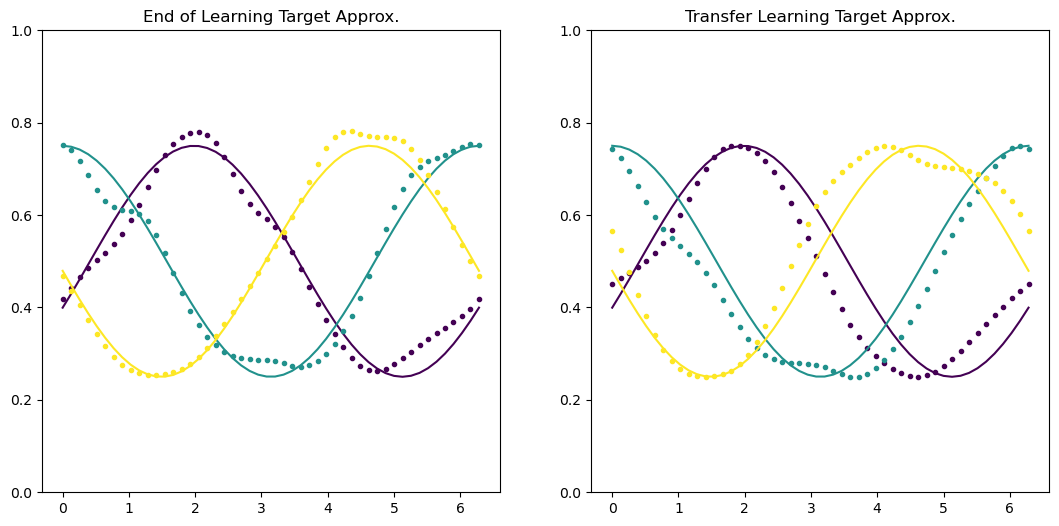

In [6]:
# POST TRAINING ---------------------
manual_weights = {}
manual_weights['L1_weights'] = MultiModel.L1_weights.detach().numpy().squeeze()
manual_weights['L1_mask'] = MultiModel.L1_mask.detach().numpy().squeeze()
manual_weights['L2_weights'] = MultiModel.L2_weights.detach().numpy().squeeze()
manual_weights['L2_mask'] = MultiModel.L2_mask.detach().numpy().squeeze()

with torch.no_grad():
    final_outputs = MultiModel(xs).detach().numpy().squeeze()

new_MultiModel = SwinehartAbbottNetworkMultiLayer(L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=conProb, manual_weights=manual_weights)
transferLearning_outputs = new_MultiModel(xs).detach().numpy().squeeze()


num_units_sample = 3
np.random.seed(42)
samp_inds = np.random.randint(0, L3_size, num_units_sample) #np.linspace(0, output_size-1, num_units_sample).astype(int)
colors = plt.cm.viridis(np.linspace(0, 1, num_units_sample))  


scaler = MinMaxScaler(feature_range=(torch.min(target_outputs).numpy(), torch.max(target_outputs).numpy()))  

plt.figure(figsize=(13, 6))

plt.subplot(1,2,1)
plt.title("End of Learning Target Approx.")
for i, targ_ind in enumerate(samp_inds):

    plt.plot(xs, target_outputs[targ_ind, :], color=colors[i])
    plt.plot(xs, final_outputs[targ_ind, :], '.', color=colors[i])
    plt.ylim([0, 1])



plt.subplot(1,2,2)
plt.title("Transfer Learning Target Approx.")
for i, targ_ind in enumerate(samp_inds):
    
    plt.plot(xs, target_outputs[targ_ind, :], color=colors[i])

    outputs_to_plot = scaler.fit_transform(transferLearning_outputs[targ_ind, :].reshape(-1, 1)) #scaler.fit_transform(transferLearning_outputs[targ_ind, :].view(-1, 1))
    plt.plot(xs, outputs_to_plot, '.', color=colors[i])
    #plt.plot(xs, transferLearning_outputs[targ_ind, :], '.', color=colors[i])
    plt.ylim([0, 1])




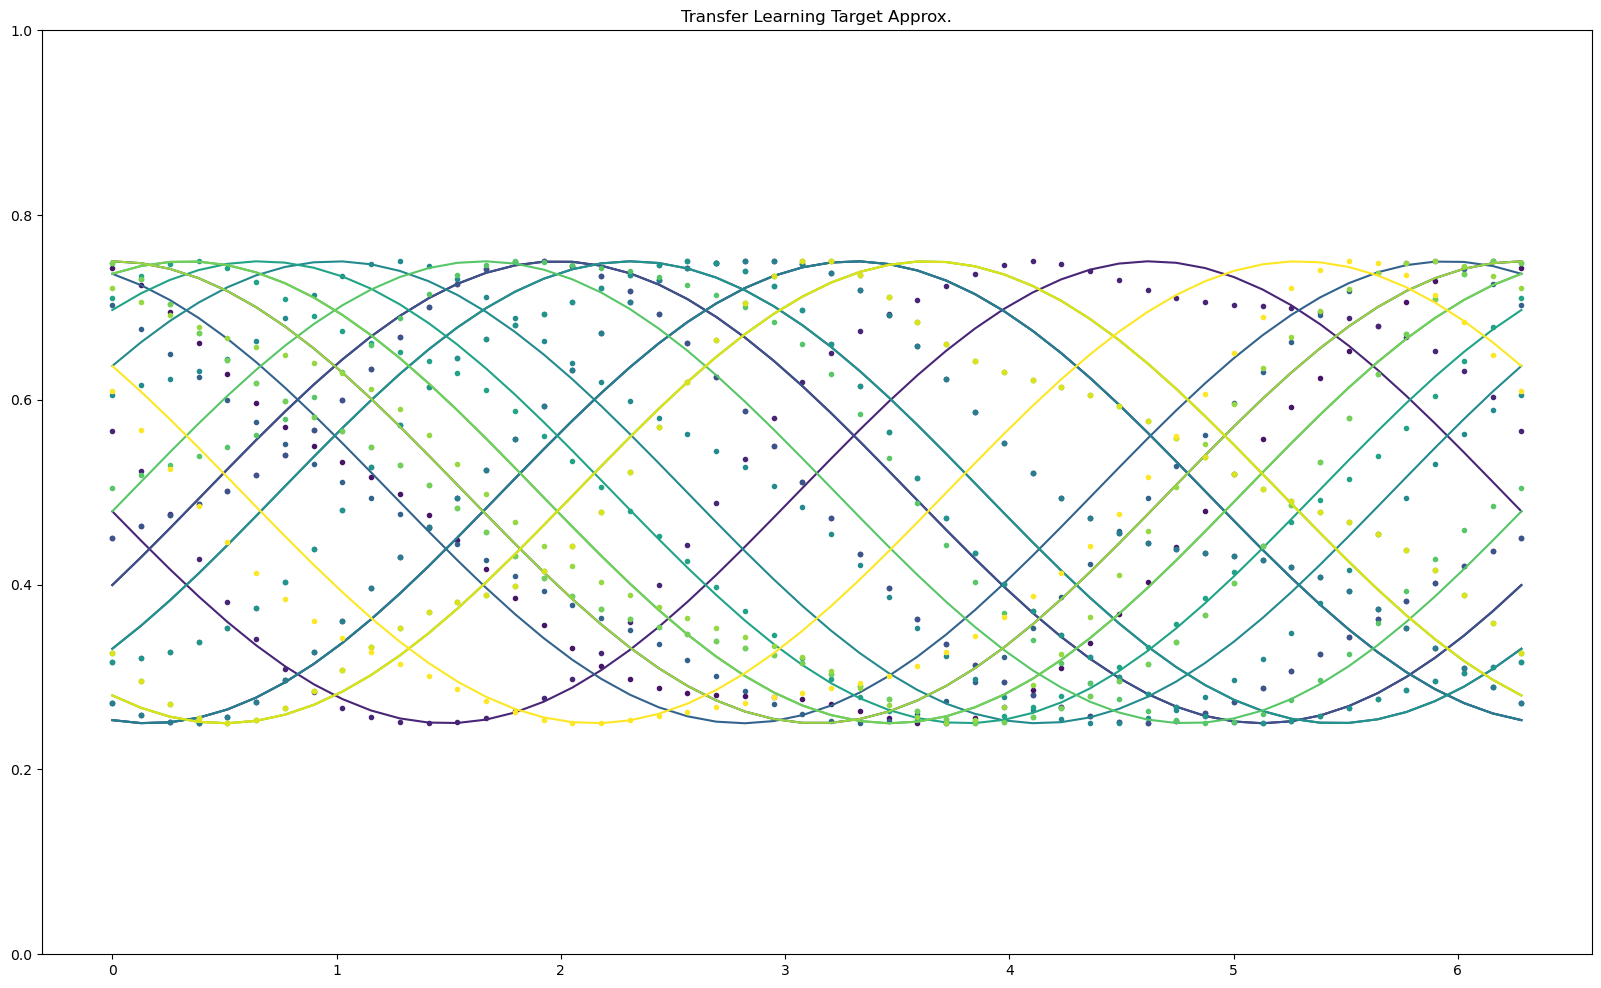

In [10]:
# POST TRAINING ---------------------
manual_weights = {}
manual_weights['L1_weights'] = MultiModel.L1_weights.detach().numpy().squeeze()
manual_weights['L1_mask'] = MultiModel.L1_mask.detach().numpy().squeeze()
manual_weights['L2_weights'] = MultiModel.L2_weights.detach().numpy().squeeze()
manual_weights['L2_mask'] = MultiModel.L2_mask.detach().numpy().squeeze()

with torch.no_grad():
    final_outputs = MultiModel(xs).detach().numpy().squeeze()

new_MultiModel = SwinehartAbbottNetworkMultiLayer(L1_size, L2_size, L3_size, init_gain, init_shift, alpha, connect_prob=conProb, manual_weights=manual_weights)
transferLearning_outputs = new_MultiModel(xs).detach().numpy().squeeze()


num_units_sample = 20
np.random.seed(42)
samp_inds = np.random.randint(0, L3_size, num_units_sample) #np.linspace(0, output_size-1, num_units_sample).astype(int)
colors = plt.cm.viridis(np.linspace(0, 1, num_units_sample))  


scaler = MinMaxScaler(feature_range=(torch.min(target_outputs).numpy(), torch.max(target_outputs).numpy()))  

plt.figure(figsize=(20, 12))


plt.title("Transfer Learning Target Approx.")
for i, targ_ind in enumerate(samp_inds):
    
    plt.plot(xs, target_outputs[targ_ind, :], color=colors[i])

    outputs_to_plot = scaler.fit_transform(transferLearning_outputs[targ_ind, :].reshape(-1, 1)) #scaler.fit_transform(transferLearning_outputs[targ_ind, :].view(-1, 1))
    plt.plot(xs, outputs_to_plot, '.', color=colors[i])
    #plt.plot(xs, transferLearning_outputs[targ_ind, :], '.', color=colors[i])
    plt.ylim([0, 1])




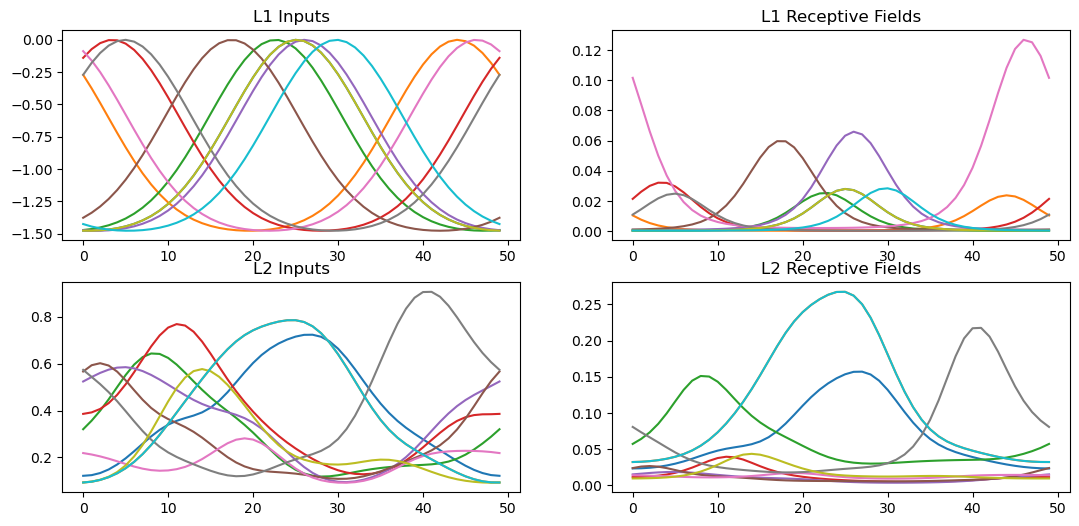

In [11]:
# Get receptive field of units across input dat
L1_receptive_fields = np.zeros((L1_size, ndata))
L2_receptive_fields = np.zeros((L2_size, ndata))
L1_inputs = np.zeros((L1_size, ndata))
L2_inputs = np.zeros((L2_size, ndata))


with torch.no_grad():

    for i, x in enumerate(xs):
        outputs = MultiModel(x)
        L1_inputs[:, i] = MultiModel.L1_inputs.detach().numpy().squeeze()
        L2_inputs[:, i] = MultiModel.L2_inputs.detach().numpy().squeeze()
        L1_receptive_fields[:, i] = MultiModel.L1_activations.detach().numpy().squeeze()
        L2_receptive_fields[:, i] = MultiModel.L2_activations.detach().numpy().squeeze()


num_units_sample = 10
np.random.seed(42)
L1_samp_inds = np.random.randint(0, L1_size, num_units_sample)  #np.linspace(0, output_size-1, num_units_sample).astype(int); colors = plt.cm.viridis(np.linspace(0, 1, num_units_sample))  
L2_samp_inds = np.random.randint(0, L2_size, num_units_sample) 


plt.figure(figsize=(13, 6))

plt.subplot(2,2,1)
plt.title("L1 Inputs")
for i, targ_ind in enumerate(L1_samp_inds):
    plt.plot(L1_inputs[targ_ind, :])

plt.subplot(2,2,2)
plt.title("L1 Receptive Fields")
for i, targ_ind in enumerate(L1_samp_inds):
    plt.plot(L1_receptive_fields[targ_ind, :])    

plt.subplot(2,2,3)
plt.title("L2 Inputs")
for i, targ_ind in enumerate(L2_samp_inds):
    plt.plot(L2_inputs[targ_ind, :])


plt.subplot(2,2,4)
plt.title("L2 Receptive Fields")
for i, targ_ind in enumerate(L2_samp_inds):
    plt.plot(L2_receptive_fields[targ_ind, :])


Text(0.5, 1.0, 'L2 Shifts')

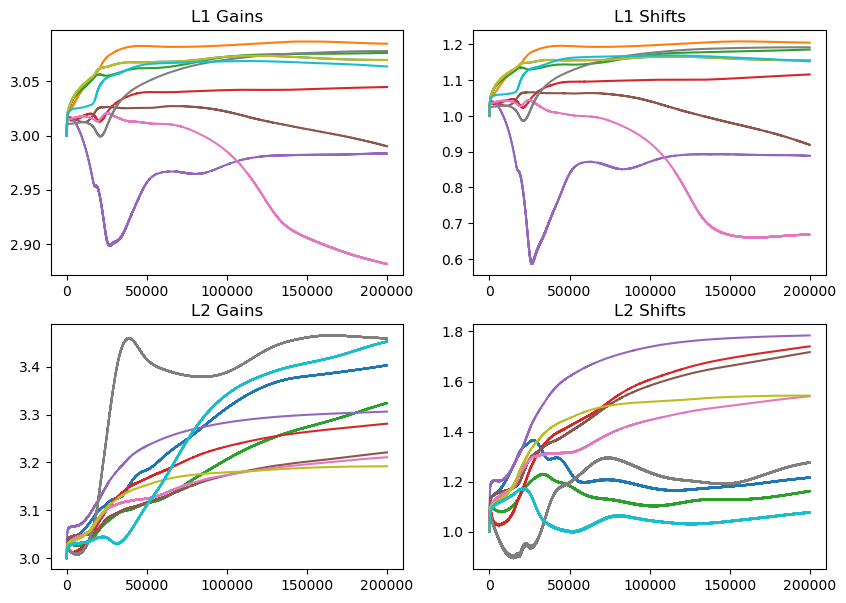

In [13]:
num_units_sample = 10
np.random.seed(42)
L1_samp_inds = np.random.randint(0, L1_size, num_units_sample) #np.linspace(0, output_size-1, num_units_sample).astype(int)
L2_samp_inds = np.random.randint(0, L2_size, num_units_sample) #np.linspace(0, output_size-1, num_units_sample).astype(int)

plt.figure(figsize=(10, 7))

plt.subplot(2,2,1)
plt.plot( np.transpose(rc_vals['L1']['gains'][L1_samp_inds, :]) );
plt.title("L1 Gains")


plt.subplot(2,2,2)
plt.plot( np.transpose(rc_vals['L1']['shifts'][L1_samp_inds, :]) );
plt.title("L1 Shifts")


plt.subplot(2,2,3)
plt.plot( np.transpose(rc_vals['L2']['gains'][L2_samp_inds, :]) );
plt.title("L2 Gains")

plt.subplot(2,2,4)
plt.plot( np.transpose(rc_vals['L2']['shifts'][L2_samp_inds, :]) );
plt.title("L2 Shifts")

